# Diagnose Suspicious Regression Results

This notebook documents the minimal checks used to understand why tree-based models achieve very high lead-time prediction performance. The goal is to distinguish direct leakage from strong synthetic, rule-like target structure before changing model regularization.

In [27]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.eda_regression_checks_utils import (
    split_summary_by_date,
    validate_required_columns,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "supply_chain_enriched_overlap.csv"
CONFIG_PATH = PROJECT_ROOT / "config" / "modeling.yaml"
MODEL_COMPARISON_PATH = PROJECT_ROOT / "results" / "lead_time_regression" / "model_comparison.csv"
CV_METRICS_PATH = PROJECT_ROOT / "results" / "lead_time_regression" / "cv_fold_metrics.csv"

TARGET = "lead_time_days"

NUMERIC_FEATURES = [
    "distance_km",
    "weight_mt",
    "fuel_price_index",
    "geopolitical_risk_score",
    "carrier_reliability_score",
    "copper__usd_per_mt",
]

CATEGORICAL_FEATURES = [
    "origin_port",
    "destination_port",
    "transport_mode",
    "product_category",
    "weather_condition",
]

EXCLUDED_COLUMNS = [
    "shipment_id",
    "date",
    "month",
    "lead_time_days",
    "disruption_occurred",
]

REQUIRED_COLUMNS = [TARGET, "date"] + NUMERIC_FEATURES + CATEGORICAL_FEATURES
FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

## 1. Load data, config, and model results

In [28]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
model_comparison = pd.read_csv(MODEL_COMPARISON_PATH)
cv_metrics = pd.read_csv(CV_METRICS_PATH)

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

test_start_date = pd.to_datetime(config["data"]["test_start_date"])

validate_required_columns(df, REQUIRED_COLUMNS)

df.shape, df["date"].min(), df["date"].max()

((2455, 16),
 Timestamp('2024-01-01 00:00:00'),
 Timestamp('2024-12-31 00:00:00'))

## 2. Summarize the suspicious performance pattern

In [29]:
model_comparison.sort_values(["model", "split"])

,model,split,mae,rmse,r2,n_rows,best_params
1,DummyRegressor,test,18.692621,27.935720,-0.000298,636,{}
0,DummyRegressor,train,18.789924,30.560238,0.000000,1819,{}
5,RandomForestRegressor,test,1.433769,2.753402,0.990283,636,"{'max_depth': None, 'min_samples_leaf': 1, 'n_..."
4,RandomForestRegressor,train,0.573055,1.239525,0.998355,1819,"{'max_depth': None, 'min_samples_leaf': 1, 'n_..."
3,RidgeRegressor,test,11.022270,17.182078,0.621591,636,{'alpha': 100.0}
2,RidgeRegressor,train,11.355590,19.331628,0.599849,1819,{'alpha': 100.0}
7,XGBoostRegressor,test,0.987242,1.737361,0.996131,636,"{'learning_rate': 0.05, 'max_depth': 5, 'min_c..."
6,XGBoostRegressor,train,0.327973,0.431568,0.999801,1819,"{'learning_rate': 0.05, 'max_depth': 5, 'min_c..."


In [30]:
model_comparison.pivot(index="model", columns="split", values="r2")

split,test,train
model,,
DummyRegressor,-0.000298,0.000000
RandomForestRegressor,0.990283,0.998355
RidgeRegressor,0.621591,0.599849
XGBoostRegressor,0.996131,0.999801


In [31]:
cv_metrics[cv_metrics["fold"].astype(str).isin(["mean", "std"])].sort_values(["model", "fold"])

,model,fold,mae,rmse,r2,n_train,n_val,best_params
4,DummyRegressor,mean,19.037143,30.720927,-0.003620,NaN,NaN,{}
5,DummyRegressor,std,1.265877,4.124878,0.004732,NaN,NaN,{}
16,RandomForestRegressor,mean,2.153357,4.545949,0.976845,NaN,NaN,"{'max_depth': None, 'min_samples_leaf': 1, 'n_..."
17,RandomForestRegressor,std,0.658930,1.334807,0.012644,NaN,NaN,"{'max_depth': None, 'min_samples_leaf': 1, 'n_..."
10,RidgeRegressor,mean,14.500996,23.725450,0.379496,NaN,NaN,{'alpha': 100.0}
11,RidgeRegressor,std,5.288386,7.541286,0.348767,NaN,NaN,{'alpha': 100.0}
22,XGBoostRegressor,mean,1.588357,3.231077,0.988187,NaN,NaN,"{'learning_rate': 0.05, 'max_depth': 5, 'min_c..."
23,XGBoostRegressor,std,0.583493,1.193763,0.008122,NaN,NaN,"{'learning_rate': 0.05, 'max_depth': 5, 'min_c..."


Tree-based models strongly outperform Ridge regression. Before changing hyperparameters, the next checks verify that no excluded or outcome-like variable is used and then test which feature groups drive the high performance.

## 3. Check for direct leakage in configured features

In [32]:
leakage_keywords = [
    "lead",
    "delay",
    "arrival",
    "delivery",
    "duration",
    "time",
    "disruption",
    "status",
    "late",
    "target",
]

suspicious_columns = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in leakage_keywords)
]

used_excluded_columns = sorted(set(FEATURE_COLUMNS) & set(EXCLUDED_COLUMNS))
used_suspicious_columns = sorted(set(FEATURE_COLUMNS) & set(suspicious_columns))

pd.DataFrame(
    {
        "check": [
            "Suspicious columns in dataset",
            "Excluded columns used as features",
            "Suspicious columns used as features",
        ],
        "result": [
            suspicious_columns,
            used_excluded_columns,
            used_suspicious_columns,
        ],
    }
)

,check,result
0,Suspicious columns in dataset,"[lead_time_days, disruption_occurred]"
1,Excluded columns used as features,[]
2,Suspicious columns used as features,[]


The configured feature list should not contain direct target, identifier, temporal split, or outcome-like columns. If `used_excluded_columns` and `used_suspicious_columns` are empty, direct leakage through configured features is unlikely.

## 4. Check train/test split sanity

In [33]:
split_summary_by_date(
    df=df,
    date_col="date",
    target_col=TARGET,
    test_start_date=test_start_date,
)

,period,n_rows,date_min,date_max,target_mean,target_median
0,development,1819,2024-01-01,2024-09-30,19.101655,8.29
1,final_test,636,2024-10-01,2024-12-31,18.619167,7.93


In [34]:
for col in ["transport_mode", "weather_condition"]:
    print(f"\n{col}")
    display(
        pd.crosstab(
            df[col],
            df["date"] >= test_start_date,
            normalize="columns",
        ).rename(columns={False: "development", True: "test"})
    )


transport_mode


date,development,test
transport_mode,,
Air,0.263881,0.272013
Rail,0.239692,0.240566
Road,0.236394,0.242138
Sea,0.260033,0.245283



weather_condition


date,development,test
weather_condition,,
Clear,0.200660,0.179245
Fog,0.203958,0.218553
Hurricane,0.201759,0.204403
Rain,0.197911,0.212264
Storm,0.195712,0.185535


Train and holdout data distributions seem very similar explaining performance of the models.

## 5. Load ablation results

In [35]:
ABLATION_NAMES = [
    "all_features",
    "without_distance",
    "without_transport_mode",
    "without_weather",
    "without_route_ports",
]

ablation_model_rows = []
ablation_cv_rows = []

for ablation_name in ABLATION_NAMES:
    result_dir = PROJECT_ROOT / "results" / f"ablation_{ablation_name}"
    model_path = result_dir / "model_comparison.csv"
    cv_path = result_dir / "cv_fold_metrics.csv"

    if not model_path.exists() or not cv_path.exists():
        raise FileNotFoundError(
            f"Missing ablation output for {ablation_name}. "
            f"Expected {model_path} and {cv_path}."
        )

    model_results = pd.read_csv(model_path)
    cv_results = pd.read_csv(cv_path)

    model_results["ablation"] = ablation_name
    cv_results["ablation"] = ablation_name

    ablation_model_rows.append(model_results)
    ablation_cv_rows.append(cv_results)

ablation_model_results = pd.concat(ablation_model_rows, ignore_index=True)
ablation_cv_results = pd.concat(ablation_cv_rows, ignore_index=True)

ablation_test_results = ablation_model_results.query("split == 'test'").copy()
ablation_cv_mean = ablation_cv_results[ablation_cv_results["fold"].astype(str) == "mean"].copy()

In [36]:
ablation_test_results.pivot(index="ablation", columns="model", values="r2").loc[ABLATION_NAMES]

model,DummyRegressor,RandomForestRegressor,RidgeRegressor,XGBoostRegressor
ablation,,,,
all_features,-0.000298,0.990283,0.621591,0.996131
without_distance,-0.000298,0.641293,0.520197,0.640646
without_transport_mode,-0.000298,0.477776,0.413331,0.483373
without_weather,-0.000298,0.277425,0.318871,0.299414
without_route_ports,-0.000298,0.990998,0.624215,0.996207


In [37]:
ablation_cv_mean.pivot(index="ablation", columns="model", values="r2").loc[ABLATION_NAMES]

model,DummyRegressor,RandomForestRegressor,RidgeRegressor,XGBoostRegressor
ablation,,,,
all_features,-0.00362,0.976845,0.379496,0.988187
without_distance,-0.00362,0.659477,0.391113,0.668042
without_transport_mode,-0.00362,0.420963,0.102144,0.405705
without_weather,-0.00362,0.337278,0.252161,0.342792
without_route_ports,-0.00362,0.978389,0.344797,0.988297


## 6. Visualize ablation impact

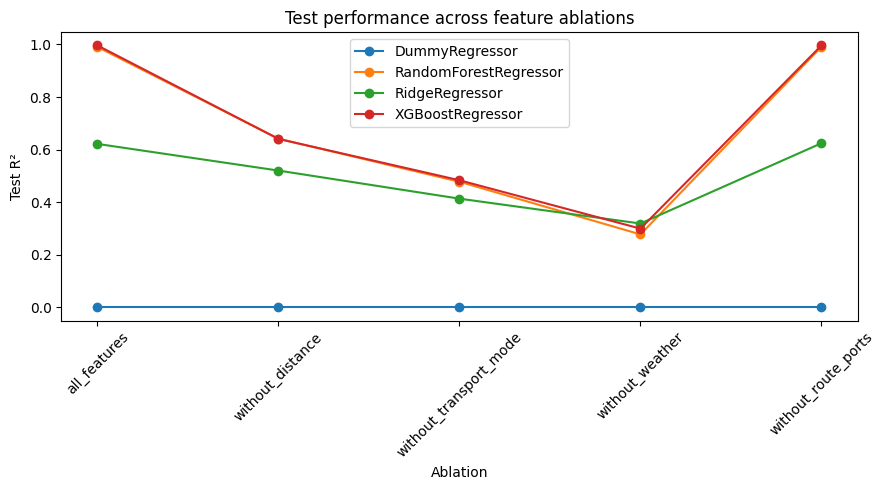

In [38]:
fig, ax = plt.subplots(figsize=(9, 5))

for model_name, model_df in ablation_test_results.groupby("model"):
    model_df = model_df.set_index("ablation").loc[ABLATION_NAMES].reset_index()
    ax.plot(model_df["ablation"], model_df["r2"], marker="o", label=model_name)

ax.set_xlabel("Ablation")
ax.set_ylabel("Test R²")
ax.set_title("Test performance across feature ablations")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

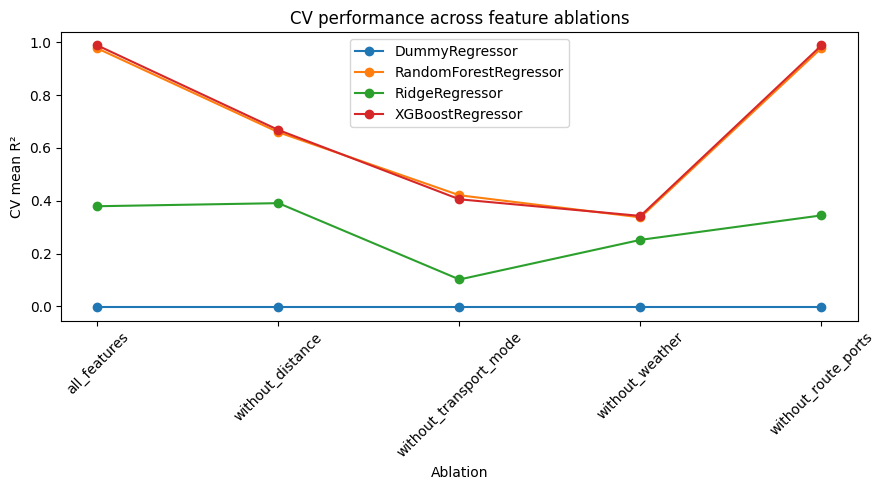

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))

for model_name, model_df in ablation_cv_mean.groupby("model"):
    model_df = model_df.set_index("ablation").loc[ABLATION_NAMES].reset_index()
    ax.plot(model_df["ablation"], model_df["r2"], marker="o", label=model_name)

ax.set_xlabel("Ablation")
ax.set_ylabel("CV mean R²")
ax.set_title("CV performance across feature ablations")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Diagnostic conclusion

- No direct leakage column was found in the configured feature list if the leakage checks above return empty lists for configured features.
- The ablation results identify `distance_km`, `transport_mode`, and especially `weather_condition` as the main drivers of the very high tree-model performance.
- Removing `origin_port` and `destination_port` does not meaningfully reduce tree-model performance, so route-port identity does not explain the near-perfect results.
- The high Random Forest and XGBoost performance is therefore most consistent with strong synthetic, rule-like target structure rather than a single obvious leakage feature.
- Next action: slightly increase regularization for tree-based models, and document the synthetic-data limitation in the project README.